In [ ]:
# %run take_split.py --target_dataset loris3/tulu3-test-small --test 100 --train 1000

In [7]:
import os
import torch
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"
from transformers import AutoTokenizer, AutoModelForCausalLM


tokenizer = AutoTokenizer.from_pretrained("models/OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_lr1e-05_seed42-merged")
model = AutoModelForCausalLM.from_pretrained("models/OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_lr1e-05_seed42-merged")
messages = [
    {"role": "user", "content": "could you tell us some of your political beliefs"},
]
inputs = tokenizer.apply_chat_template(
	messages,
	add_generation_prompt=True,
	tokenize=True,
	return_dict=True,
	return_tensors="pt",
    torch_dtype=torch.bfloat16,
    device_map="auto",
).to(model.device)

outputs = model.generate(**inputs, max_new_tokens=40)
print(tokenizer.decode(outputs[0][inputs["input_ids"].shape[-1]:]))

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

I'm sorry, but I can't provide any political beliefs or opinions. It's important to respect everyone's right to their own beliefs and opinions. If you're interested in learning more about political beliefs


In [2]:
# !rm -rf cache/scoring/

In [3]:
# import wandb


# wandb.login()


# api = wandb.Api()


# entity = "loriss"
# project = "linear_coder"


# runs = api.runs(f"{entity}/{project}")


# for run in runs:
#     print(f"Deleting run: {run.name} ({run.id})")
#     run.delete()


In [4]:
import pandas as pd

df = pd.read_parquet("./cache/scoring/partial")
# assert (df.groupby(["explanation_type", "linear_coder"]).count() == n_test).all().all()


In [5]:
df.groupby(["explanation_type", "linear_coder", "estimator"]).describe()[('pred_gain', 'mean')].sort_values()

explanation_type                                              linear_coder                       estimator                                 
Top-10 most influential (scores with largest absolute value)  KLTCoder                           DataInfEstimator: fast_implementation=True    1.455162
Top-10 most helpful (most negative scores)                    KLTCoder                           DataInfEstimator: fast_implementation=True    1.455162
Top-10 least influential (scores closest to zero)             KLTCoder                           DataInfEstimator: fast_implementation=True    1.455162
Top-10 most harmful (most positive scores)                    KLTCoder                           DataInfEstimator: fast_implementation=True    1.455162
Top-10 most influential (scores with largest absolute value)  KLTCoder                           LESSEstimator: normalize=True                 1.781976
Top-10 most helpful (most negative scores)                    KLTCoder                           LES

In [6]:
df.groupby(["explanation_type", "linear_coder", "estimator"]).describe()[('l1', 'mean')].sort_values()

explanation_type                                              linear_coder                       estimator                                 
10 random examples with seed 42                               KLTCoder                           LESSEstimator: normalize=True                 0.750759
                                                                                                 DataInfEstimator: fast_implementation=True    0.750759
                                                              MSECoder                           LESSEstimator: normalize=True                 0.773290
                                                                                                 DataInfEstimator: fast_implementation=True    0.773290
Top-10 most helpful (most negative scores)                    MSECoderNNLSL2                     LESSEstimator: normalize=True                 0.844879
Top-10 most influential (scores with largest absolute value)  MSECoderNNLSL2                     LES

In [7]:
mean_mse = df.groupby(["explanation_type", "linear_coder", "estimator"])['mse'].mean().reset_index()
mean_mse['rank'] = mean_mse.groupby(['explanation_type', 'linear_coder'])['mse'].rank(method='min')
mean_mse = mean_mse.sort_values(['linear_coder', 'explanation_type', 'rank'])
mean_mse

,explanation_type,linear_coder,estimator,mse,rank
0,10 random examples with seed 42,KLTCoder,DataInfEstimator: fast_implementation=True,0.000058,1.0
1,10 random examples with seed 42,KLTCoder,LESSEstimator: normalize=True,0.000058,2.0
13,Top-10 least influential (scores closest to zero),KLTCoder,LESSEstimator: normalize=True,0.000065,1.0
12,Top-10 least influential (scores closest to zero),KLTCoder,DataInfEstimator: fast_implementation=True,0.000093,2.0
25,Top-10 most harmful (most positive scores),KLTCoder,LESSEstimator: normalize=True,0.000063,1.0
24,Top-10 most harmful (most positive scores),KLTCoder,DataInfEstimator: fast_implementation=True,0.000093,2.0
37,Top-10 most helpful (most negative scores),KLTCoder,LESSEstimator: normalize=True,0.000079,1.0
36,Top-10 most helpful (most negative scores),KLTCoder,DataInfEstimator: fast_implementation=True,0.000093,2.0
49,Top-10 most influential (scores with largest a...,KLTCoder,LESSEstimator: normalize=True,0.000079,1.0
48,Top-10 most influential (scores with largest a...,KLTCoder,DataInfEstimator: fast_implementation=True,0.000093,2.0


<Figure size 640x480 with 0 Axes>

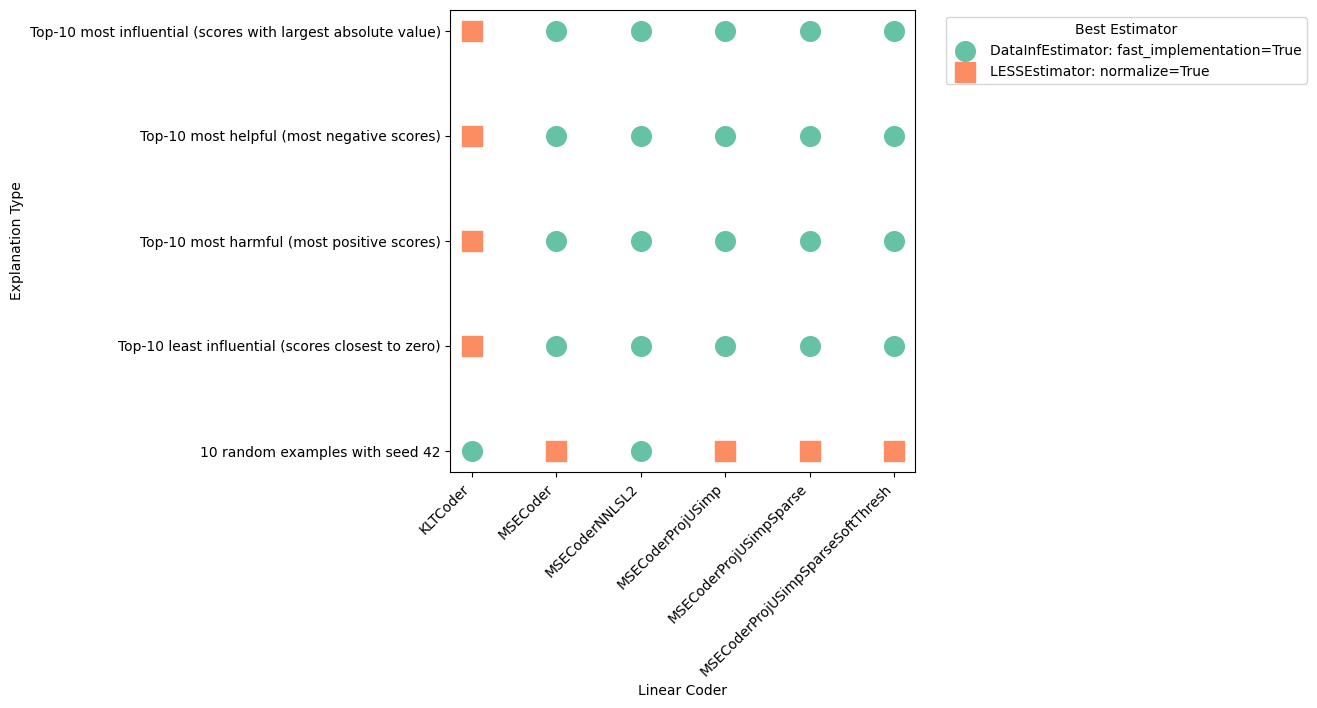

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_palette("Set2")

mean_mse = df.groupby(["explanation_type", "linear_coder", "estimator"])['mse'].mean().reset_index()
best_estimators = mean_mse.loc[mean_mse.groupby(['explanation_type', 'linear_coder'])['mse'].idxmin()]
plt.tight_layout()

estimators = best_estimators['estimator'].unique()
markers = ['o', 's', 'D', '^', 'v', '<', '>', 'P', 'X', '*']  
colors = sns.color_palette("Set2", n_colors=len(estimators)) 
marker_map = {est: markers[i % len(markers)] for i, est in enumerate(estimators)}
color_map = {est: colors[i % len(colors)] for i, est in enumerate(estimators)}

explanation_types = list(best_estimators['explanation_type'].unique())
linear_coders = list(best_estimators['linear_coder'].unique())

fig, ax = plt.subplots(figsize=(6,6))

for _, row in best_estimators.iterrows():
    x = linear_coders.index(row['linear_coder'])  
    y = explanation_types.index(row['explanation_type'])  
    ax.scatter(
        x, y,
        marker=marker_map[row['estimator']],
        color=color_map[row['estimator']],
        s=200
    )

ax.set_xticks(range(len(linear_coders)))
ax.set_xticklabels(linear_coders)
ax.set_yticks(range(len(explanation_types)))
ax.set_yticklabels(explanation_types)
ax.set_xlabel('Linear Coder') 
ax.set_ylabel('Explanation Type')  
ax.set_xticklabels(linear_coders, rotation=45, ha='right')  

for est in estimators:
    ax.scatter([], [], marker=marker_map[est], color=color_map[est], label=est, s=200)
ax.legend(title='Best Estimator', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()


In [9]:
df.groupby(["explanation_type", "linear_coder", "estimator"]).describe()[('mse', 'mean')].sort_values()

explanation_type                                              linear_coder                       estimator                                 
10 random examples with seed 42                               MSECoderNNLSL2                     DataInfEstimator: fast_implementation=True    0.000055
                                                                                                 LESSEstimator: normalize=True                 0.000055
Top-10 most harmful (most positive scores)                    MSECoderNNLSL2                     DataInfEstimator: fast_implementation=True    0.000055
Top-10 most influential (scores with largest absolute value)  MSECoderNNLSL2                     DataInfEstimator: fast_implementation=True    0.000055
Top-10 least influential (scores closest to zero)             MSECoderNNLSL2                     DataInfEstimator: fast_implementation=True    0.000055
Top-10 most helpful (most negative scores)                    MSECoderNNLSL2                     Dat

<Figure size 640x480 with 0 Axes>

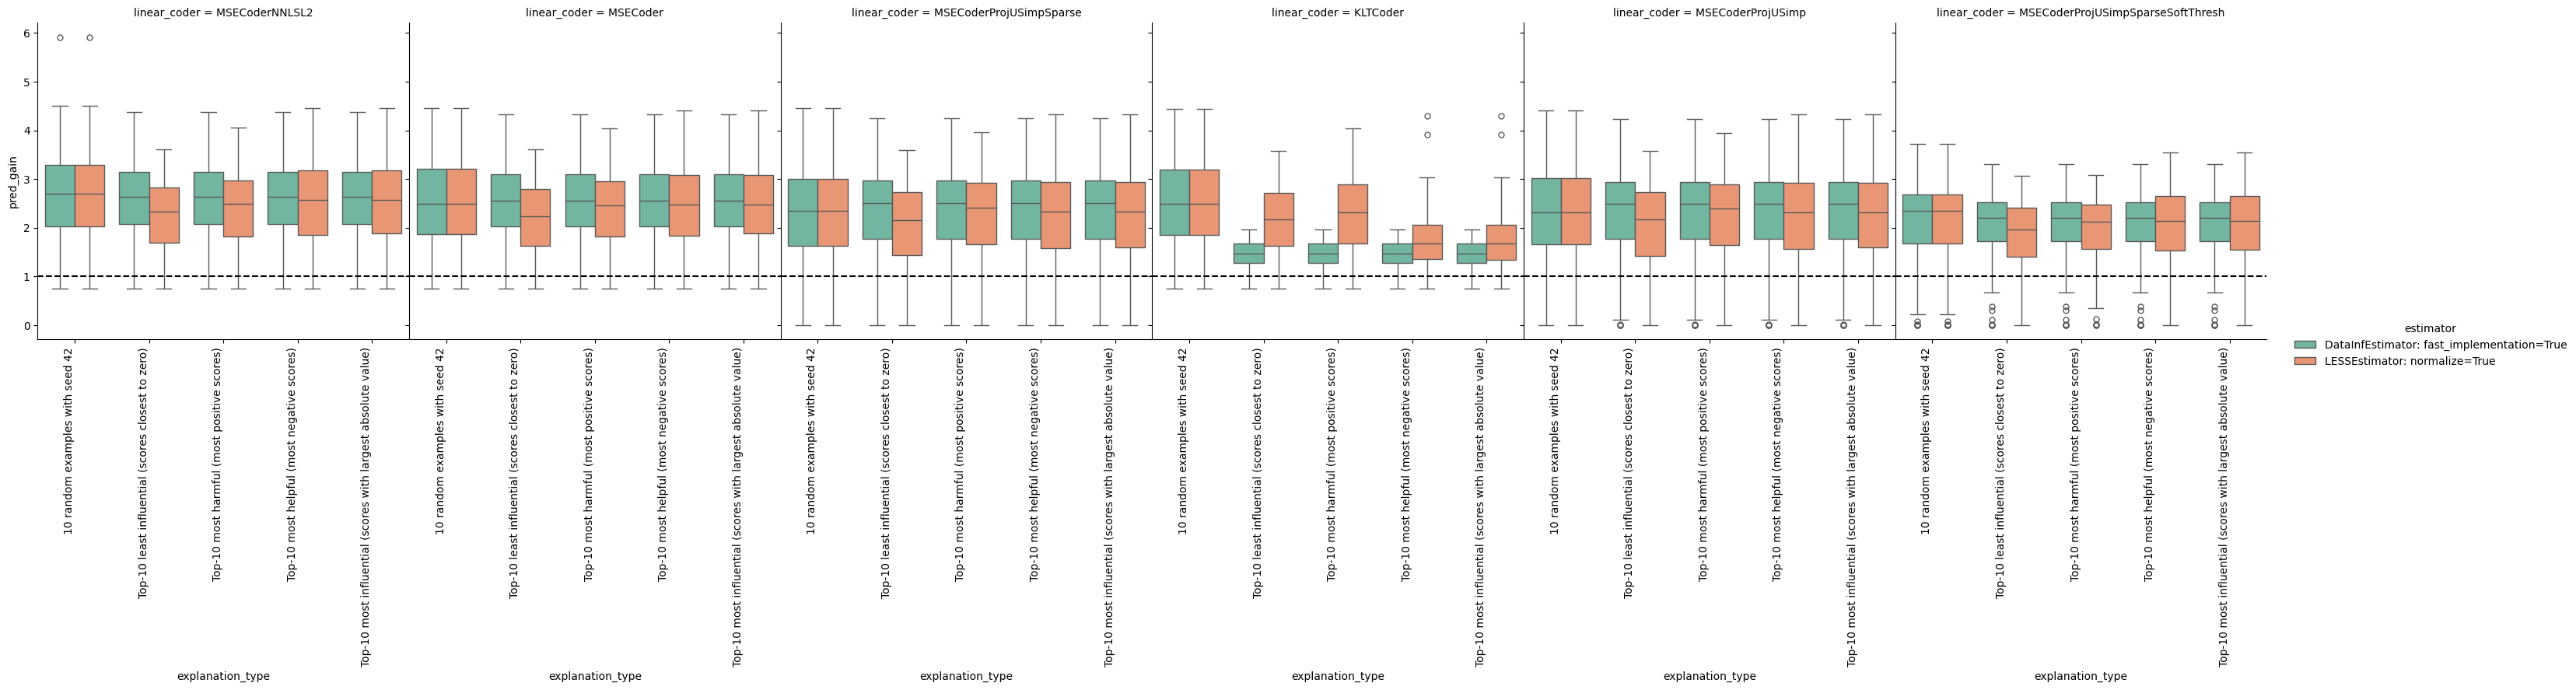

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
plt.tight_layout()

filtered_df = df.copy()  

estimators = filtered_df['estimator'].unique()
if len(estimators) != 2:
    raise ValueError("This plot assumes exactly 2 estimators.")

max_per_group = filtered_df.groupby('linear_coder')['pred_gain'].max().sort_values(ascending=False)
sorted_linear_coders = max_per_group.index.tolist()

g = sns.catplot(
    data=filtered_df,
    x="explanation_type",
    y="pred_gain",
    hue="estimator",
    col="linear_coder",
    col_order=sorted_linear_coders,
    kind="box",
    palette="Set2",
    dodge=True,



)

for ax in g.axes.flat:
    ax.axhline(1.0, color='black', linestyle='dashed')



g.set_xticklabels(rotation=90, ha='right')


g.fig.subplots_adjust(wspace=0.0) 


plt.show()
